In [272]:
import os
import torch
import clip
import sys
import torch.nn.functional as F
from tqdm import tqdm
from src.models.architectures.transformer import Encoder_TRANSFORMER, Decoder_TRANSFORMER
from src.models.modeltype.motionclip import MOTIONCLIP
from src.utils.get_model_and_data import get_model_and_data
from src.parser.visualize import parser
from src.utils.misc import load_model_wo_clip
from sklearn.metrics.pairwise import cosine_similarity
from src.visualize.visualize import get_gpu_device
from src.utils.tensors import collate
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from src.utils.action_label_to_idx import action_label_to_idx
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [273]:
os.environ["CLIP_CACHE_DIR"] = "D:/clip_cache"
device = "cuda" if torch.cuda.is_available() else "cpu"

### Get the model

In [274]:
print(os.getcwd())
sys.argv = ["notebook", "../classes-model/checkpoint_0200.pth.tar"]

d:\Delft\Uni\Thesis\MotionCLIP_experiment\MotionCLIP


In [275]:
parameters, folder, checkpointname, epoch = parser(checkpoint=True)
# gpu_device = get_gpu_device()
parameters["device"] = device
data_split = 'vald'  # Hardcoded
parameters['use_action_cat_as_text_labels'] = True
parameters['only_60_classes'] = True

TOP_K_METRIC = 5

model, datasets = get_model_and_data(parameters, split=data_split)
dataset = datasets["train"]

print("Restore weights..")
checkpointpath = os.path.join(folder, checkpointname)
state_dict = torch.load(checkpointpath, map_location=parameters["device"])
load_model_wo_clip(model, state_dict)
model.eval()

datapath used by amass is [./data/amass_db/babel_30fps_vald.pt]
datapath used by amass is [./data/amass_db/babel_30fps_vald.pt]


d:\anaconda3\envs\motionclip\lib\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Restore weights..


C:\Users\meenakshi\AppData\Local\Temp\ipykernel_8716\2688814868.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpointpath, map_location=par

MOTIONCLIP(
  (encoder): Encoder_TRANSFORMER(
    (skelEmbedding): Linear(in_features=150, out_features=512, bias=True)
    (sequence_pos_encoder): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (seqTransEncoder): TransformerEncoder(
      (layers): ModuleList(
        (0-7): 8 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
          )
          (linear1): Linear(in_features=512, out_features=1024, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=1024, out_features=512, bias=True)
          (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (decoder): Decoder_TRANSFO

In [276]:
iterator = DataLoader(dataset, batch_size=parameters["batch_size"],
                          shuffle=False, num_workers=8, collate_fn=collate)

In [277]:
print(len(iterator))

383


### Get text embeddings

In [278]:
action_text_labels = list(action_label_to_idx.keys())
action_text_labels.sort(key=lambda x: action_label_to_idx[x])

texts = clip.tokenize(action_text_labels[:60]).to(model.device)
classes_text_emb = model.clip_model.encode_text(texts).float()

### Compute action recognition accuracies

In [16]:
correct_preds_top_5, correct_preds_top_1 = 0,0
total_samples = 0
with torch.no_grad():
    for i, batch in tqdm(enumerate(iterator), desc="Computing batch"):
        if isinstance(batch['x'], list):
            continue
        for key in batch.keys():
            if torch.is_tensor(batch[key]):
                batch[key] = batch[key].to(parameters['device'])
        batch = model(batch)
        texts = clip.tokenize(batch['clip_text']).to(model.device)
        batch['clip_text_embed'] = model.clip_model.encode_text(texts).float()
        labels = list(map(lambda x: [action_label_to_idx[cat] for cat in x], batch['all_categories']))
        classes_text_emb_norm = classes_text_emb / classes_text_emb.norm(dim=-1, keepdim=True)
        motion_features_norm = batch['z'] / batch['z'].norm(dim=-1, keepdim=True)
        scores = motion_features_norm @ classes_text_emb_norm.t()
        similarity = (100.0 * motion_features_norm @ classes_text_emb_norm.t()).softmax(dim=-1)

        total_samples += similarity.shape[0]
        for i in range(similarity.shape[0]):
            values, indices = similarity[i].topk(5)

            # TOP-5 CHECK
            if any([gt_cat_idx in indices for gt_cat_idx in labels[i]]):
                correct_preds_top_5 += 1

            # TOP-1 CHECK
            values = values[:1]
            indices = indices[:1]
            if any([gt_cat_idx in indices for gt_cat_idx in labels[i]]):
                correct_preds_top_1 += 1
    print(f"Top-5 Acc. : {100 * correct_preds_top_5 / total_samples:.2f}%  ({correct_preds_top_5}/{total_samples})")
    print(f"Top-1 Acc. : {100 * correct_preds_top_1 / total_samples:.2f}%  ({correct_preds_top_1}/{total_samples})")


Computing batch: 383it [6:06:36, 57.43s/it]

Top-5 Acc. : 57.46%  (3971/6911)
Top-1 Acc. : 40.31%  (2786/6911)


In [279]:
correct_preds_top_5, correct_preds_top_1 = 0,0
total_samples = 0
with torch.no_grad():
    all_motion_embeds = []
    all_labels = []
    all_similarities = []
    for i, batch in tqdm(enumerate(iterator), desc="Computing batch"):
        if isinstance(batch['x'], list):
            continue
        for key in batch.keys():
            if torch.is_tensor(batch[key]):
                batch[key] = batch[key].to(parameters['device'])
        batch = model(batch)
        texts = clip.tokenize(batch['clip_text']).to(model.device)
        batch['clip_text_embed'] = model.clip_model.encode_text(texts).float()
        labels = list(map(lambda x: [action_label_to_idx[cat] for cat in x], batch['all_categories']))
        classes_text_emb_norm = classes_text_emb / classes_text_emb.norm(dim=-1, keepdim=True)
        motion_features_norm = batch['z'] / batch['z'].norm(dim=-1, keepdim=True)
        scores = motion_features_norm @ classes_text_emb_norm.t()
        similarity = (100.0 * motion_features_norm @ classes_text_emb_norm.t()).softmax(dim=-1)

        all_motion_embeds.append(motion_features_norm.cpu())
        all_labels.extend(labels)
        all_similarities.append(scores.cpu())


        total_samples += similarity.shape[0]
        for i in range(similarity.shape[0]):
            values, indices = similarity[i].topk(5)

            # TOP-5 CHECK
            if any([gt_cat_idx in indices for gt_cat_idx in labels[i]]):
                correct_preds_top_5 += 1

            # TOP-1 CHECK
            values = values[:1]
            indices = indices[:1]
            if any([gt_cat_idx in indices for gt_cat_idx in labels[i]]):
                correct_preds_top_1 += 1
    print(f"Top-5 Acc. : {100 * correct_preds_top_5 / total_samples:.2f}%  ({correct_preds_top_5}/{total_samples})")
    print(f"Top-1 Acc. : {100 * correct_preds_top_1 / total_samples:.2f}%  ({correct_preds_top_1}/{total_samples})")

    torch.save(
    {
        "motion_embeddings": torch.cat(all_motion_embeds, dim=0),  # (N, D)
        "labels": all_labels,                                       # list of lists
        "similarities": torch.cat(all_similarities, dim=0),         # (N, 60)
    },
    "motionclip_action_recognition_outputs_cosineScores.pt"
    )


Computing batch: 383it [6:13:03, 58.44s/it]

Top-5 Acc. : 57.66%  (3985/6911)
Top-1 Acc. : 40.54%  (2802/6911)


In [52]:
motion_embeddings_labels = torch.load("motionclip_action_recognition_outputs.pt")
print(len(motion_embeddings_labels["motion_embeddings"]))
print(len(motion_embeddings_labels["labels"]))
print(len(motion_embeddings_labels["similarities"]))

6920
6920
6920


C:\Users\meenakshi\AppData\Local\Temp\ipykernel_8716\2126824045.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  motion_embeddings_labels = torch.load("motionclip_action_

In [160]:
from collections import Counter

labels = motion_embeddings_labels["labels"]   # length N, each element is list[int]

label_counter = Counter()

for lbls in labels:
    for lbl in lbls:
        label_counter[lbl] += 1

In [161]:
num_labels = 60
counts = [label_counter.get(i, 0) for i in range(num_labels)]

In [163]:
print(counts)

[1746, 1010, 699, 237, 477, 701, 859, 220, 160, 269, 134, 118, 58, 141, 401, 177, 77, 110, 318, 26, 138, 107, 115, 42, 49, 62, 22, 46, 122, 92, 32, 52, 117, 65, 71, 92, 12, 23, 49, 70, 41, 84, 7, 257, 46, 43, 57, 50, 32, 88, 121, 17, 11, 12, 13, 42, 17, 18, 160, 35]


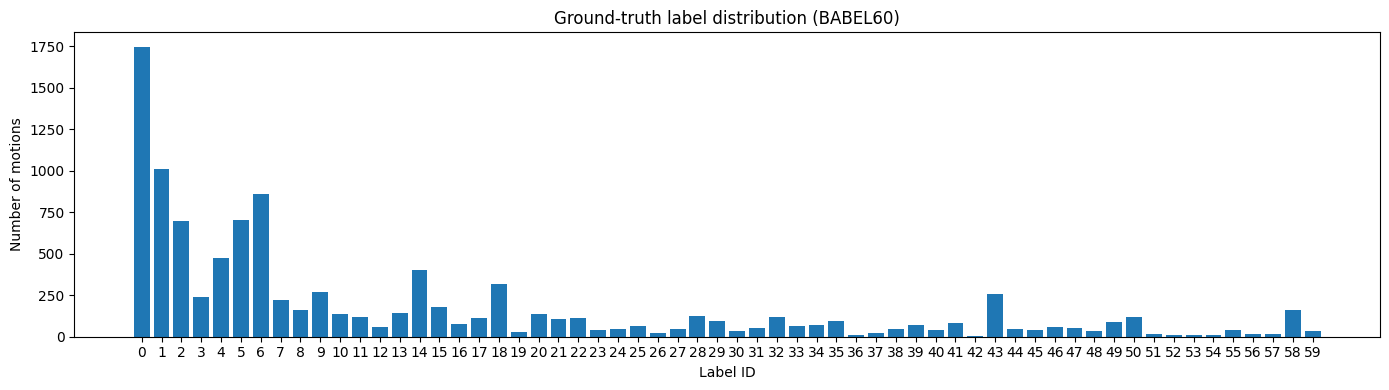

In [162]:
plt.figure(figsize=(14, 4))
plt.bar(range(num_labels), counts)

plt.xticks(range(num_labels))
plt.xlabel("Label ID")
plt.ylabel("Number of motions")
plt.title("Ground-truth label distribution (BABEL60)")
plt.tight_layout()
plt.show()


### Encode anomaly prompts

In [420]:
# anomaly_prompts = ["look", "real fight", "punch or kick", "punch, kick or push", "punch, kick or push related to violence", "punch, kick or push related to fighting"] 
# anomaly_prompts = ["fall while walking", "loss of balance while moving", "person stumbling or nearly falling", "one arm moving differently than the other", "limbs moving out of sync", "erractic hand movements"] 
# anomaly_prompts = ["fall while walking", "loss of balance while moving", "a person maintaining stable balance while moving", "person stumbling or nearly falling", "a person walking with steady and controlled movement",
#                    "one arm moving differently than the other", "both arms moving symmetrically", "limbs moving out of sync", "limbs moving in a coordinated and synchronized way"] 
anomaly_prompts = ["quantum field theory lagrangian", "no people, no motion, no objects, abstract pattern only", "empty mathematical diagram","pure noise texture"]
# ]
# anomaly_prompts = ["a person walking normally", 
# "a person standing still" , 
# "a person standing upright in a neutral pose", 
# "a person making natural hand movements", 
# "a person moving their arms naturally",
# "a person in a relaxed standing pose"]
# anomaly_prompts = ["walk", "stand", "hand movements", "turn", "arm movements", "t pose","catch", "squat", "throw", "dance"]


In [421]:
def encode_anomaly_prompts(model, anomaly_prompts):
    texts = clip.tokenize(anomaly_prompts).to(model.device)
    with torch.no_grad():
        z_t = model.clip_model.encode_text(texts).float()
    z_t = z_t / z_t.norm(dim=-1, keepdim=True)
    return z_t  # (P, D)

In [422]:
encoded_prompts = encode_anomaly_prompts(model, anomaly_prompts)

### Pick one motion per label

In [371]:
def pick_one_motion_per_label(motion_embeddings, labels, num_labels=60):
    """
    motion_embeddings: Tensor (N, D)
    labels: length-N iterable; each element is either an int label or a list/tuple of int labels
    num_labels: 60 for BABEL60

    Returns:
        selected_embeds: Tensor (num_labels, D)  (may contain None entries if some labels never appear)
        selected_indices: list length num_labels with chosen motion index or None
    """
    selected_indices = [None] * num_labels

    for i, lbls in enumerate(labels):
        # normalize to a list of ints
        if isinstance(lbls, (int,)):
            lbls = [lbls]

        for lbl in lbls:
            if 0 <= lbl < num_labels and selected_indices[lbl] is None:
                selected_indices[lbl] = i

        if all(idx is not None for idx in selected_indices):
            break

    selected_embeds = [
        motion_embeddings[idx] if idx is not None else None
        for idx in selected_indices
    ]

    return selected_embeds, selected_indices


In [372]:
#the indices of selected_motion_embeds is the label of that motion
selected_motion_embeds, _ = pick_one_motion_per_label(motion_embeddings_labels["motion_embeddings"], motion_embeddings_labels["labels"])

### Compute similarity

In [373]:
def compute_similarity(
    selected_embeds,   # list of length 60, each (D,) or None
    z_t                # (P, D)
):
    """
    Returns:
        similarities: Tensor (60, P) with NaNs for missing labels
    """
    num_labels = len(selected_embeds)
    P = z_t.shape[0]

    similarities = torch.full((num_labels, P), float("nan"))

    for lbl, z_m in enumerate(selected_embeds):
        if z_m is None:
            continue
        similarities[lbl] = z_t @ z_m   # (P,)

    return similarities


In [374]:
similarity_scores = compute_similarity(selected_motion_embeds, encoded_prompts)
print(similarity_scores)

tensor([[0.7436],
        [0.7750],
        [0.7372],
        [0.7771],
        [0.6928],
        [0.7529],
        [0.6411],
        [0.7148],
        [0.7335],
        [0.7529],
        [0.7797],
        [0.7275],
        [0.6890],
        [0.7245],
        [0.7468],
        [0.7378],
        [0.7734],
        [0.7053],
        [0.7870],
        [0.7007],
        [0.7260],
        [0.7335],
        [0.7781],
        [0.7088],
        [0.7734],
        [0.7802],
        [0.7515],
        [0.7746],
        [0.7105],
        [0.7525],
        [0.7275],
        [0.7258],
        [0.7052],
        [0.7199],
        [0.7529],
        [0.7071],
        [0.7855],
        [0.7400],
        [0.7198],
        [0.7052],
        [0.6789],
        [0.7890],
        [0.7186],
        [0.7105],
        [0.7470],
        [0.7052],
        [0.7002],
        [0.7288],
        [0.7372],
        [0.7378],
        [0.7161],
        [0.7048],
        [0.7476],
        [0.7103],
        [0.7321],
        [0

### Plot heatmap

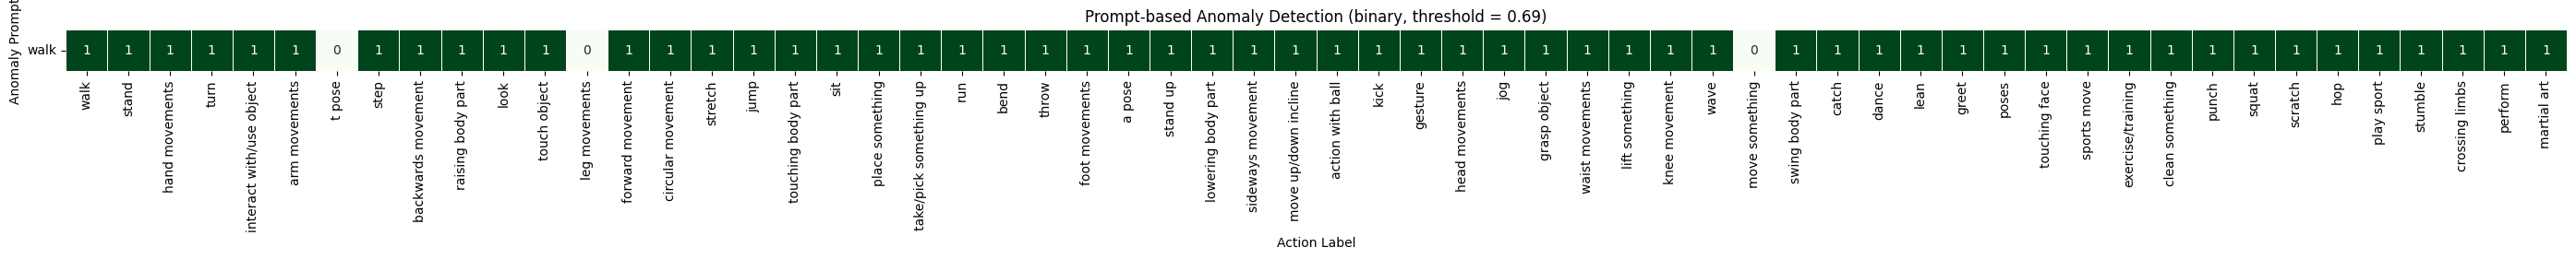

In [375]:
idx_to_action_label = {v: k for k, v in action_label_to_idx.items()}
threshold = 0.69

# similarity_scores: (60, P)
# we want rows = prompts, cols = labels
binary_anomaly = (similarity_scores.T >= threshold).int()  # (P, 60)

binary_df = pd.DataFrame(
    binary_anomaly.cpu().numpy(),
    index=anomaly_prompts,
    columns=[idx_to_action_label[lbl] for lbl in range(60)]
)
plt.figure(figsize=(28, 10))

sns.heatmap(
    binary_df,
    cmap="Greens",
    cbar=False,
    annot=True,
    fmt="d",
    square=True,
    linewidths=0.5
)

plt.title(f"Prompt-based Anomaly Detection (binary, threshold = {threshold})")
plt.xlabel("Action Label")
plt.ylabel("Anomaly Prompt")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

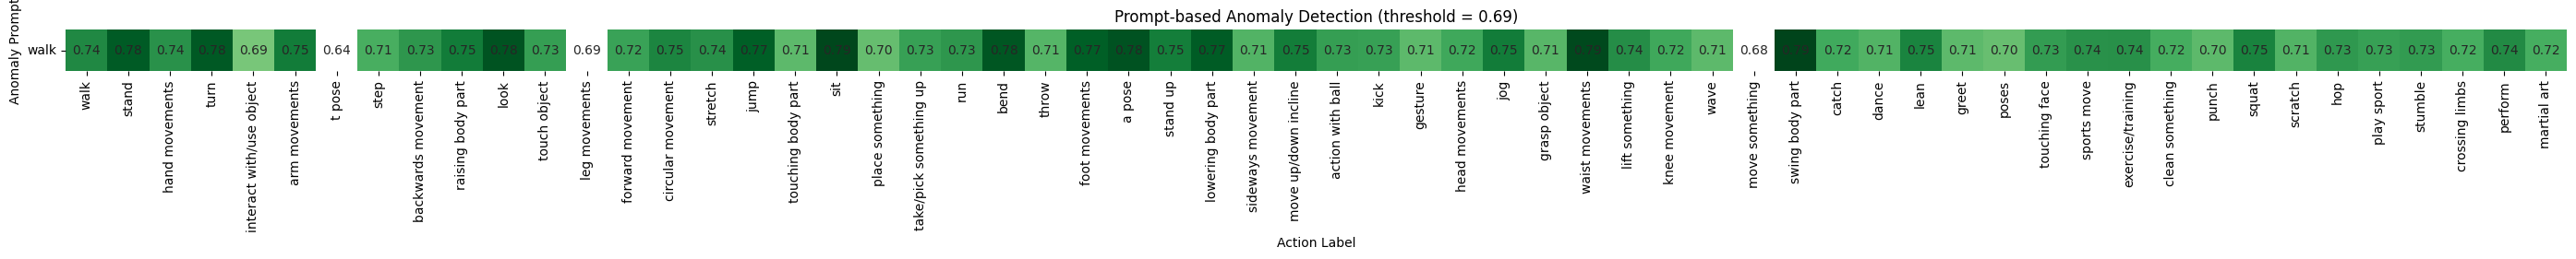

In [376]:
idx_to_action_label = {v: k for k, v in action_label_to_idx.items()}
threshold = 0.69
scores_df = pd.DataFrame(
    similarity_scores.T.cpu().numpy(),
    index=anomaly_prompts,
    columns=[idx_to_action_label[lbl] for lbl in range(60)]
)
mask = scores_df < threshold
plt.figure(figsize=(28, 10))

# Base layer: show all scores as numbers, white background
sns.heatmap(
    scores_df,
    cmap=["white"],
    cbar=False,
    annot=scores_df.round(2),
    fmt=".2f",
    square=True,
    linewidths=0.5
)

# Overlay: highlight only scores >= threshold in green
sns.heatmap(
    scores_df,
    mask=mask,
    cmap="Greens",
    vmin=0.6,
    vmax=scores_df.values.max(),
    cbar=False,
    annot=False,
    square=True
)

plt.title(f"Prompt-based Anomaly Detection (threshold = {threshold})")
plt.xlabel("Action Label")
plt.ylabel("Anomaly Prompt")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Heatmap of the motionCLIP Action Recognition experiment

In [135]:
similarities = motion_embeddings_labels["similarities"]
labels = motion_embeddings_labels["labels"]
predicted_class = similarities.argmax(dim=1)   # (N,)
predicted_score = similarities.max(dim=1).values

In [136]:
rows = []
for i in range(len(labels)):
    gt = labels[i]                       # list[int]
    pred = predicted_class[i].item()
    conf = predicted_score[i].item()

    rows.append({
        "motion_id": i,
        "ground_truth": gt,
        "predicted": pred,
        "correct": pred in gt,
        "confidence": conf
    })

df = pd.DataFrame(rows)

[[43, 28], [43, 28], [43, 28], [21, 8], [0], [0], [0], [7], [33], [33], [8], [8], [43], [43], [1], [1, 0], [0], [1], [26], [43, 28], [43, 28], [43, 28], [37], [4], [37, 4, 40], [37, 4, 40], [59, 4], [59, 4], [59, 4], [59, 4], [59, 4], [43], [43], [43], [43], [43], [43], [1, 31], [1, 31], [43], [43], [43], [8, 31], [31], [16, 24, 21], [3], [1], [0], [5, 9], [1], [55], [55], [34], [34], [34], [34], [22], [0, 14], [0, 14], [0, 14], [0, 14], [0], [0], [0], [0], [0], [0], [1], [1], [1], [49, 15, 5], [49, 15, 5], [49, 15, 5], [49, 15, 5], [0], [0], [0], [0], [1], [1], [30, 4, 11], [16], [13], [34], [34], [34], [34], [1], [1], [1], [0], [0], [0], [0], [21], [21], [21], [21], [0], [0], [0], [0], [1], [1], [1], [42], [0], [0], [0], [0], [0], [0], [0], [21], [21], [21], [0], [0], [1], [0], [0], [0, 49], [0, 49], [0, 49], [22, 0], [16], [9, 5], [31, 24, 30, 4], [0], [0], [0], [0], [1, 22, 38, 5], [0], [3], [18], [52, 0], [0], [16], [0], [0], [0], [0], [0], [0], [0], [0], [21], [21], [21], [21], [

In [137]:
print(len(df))

6920


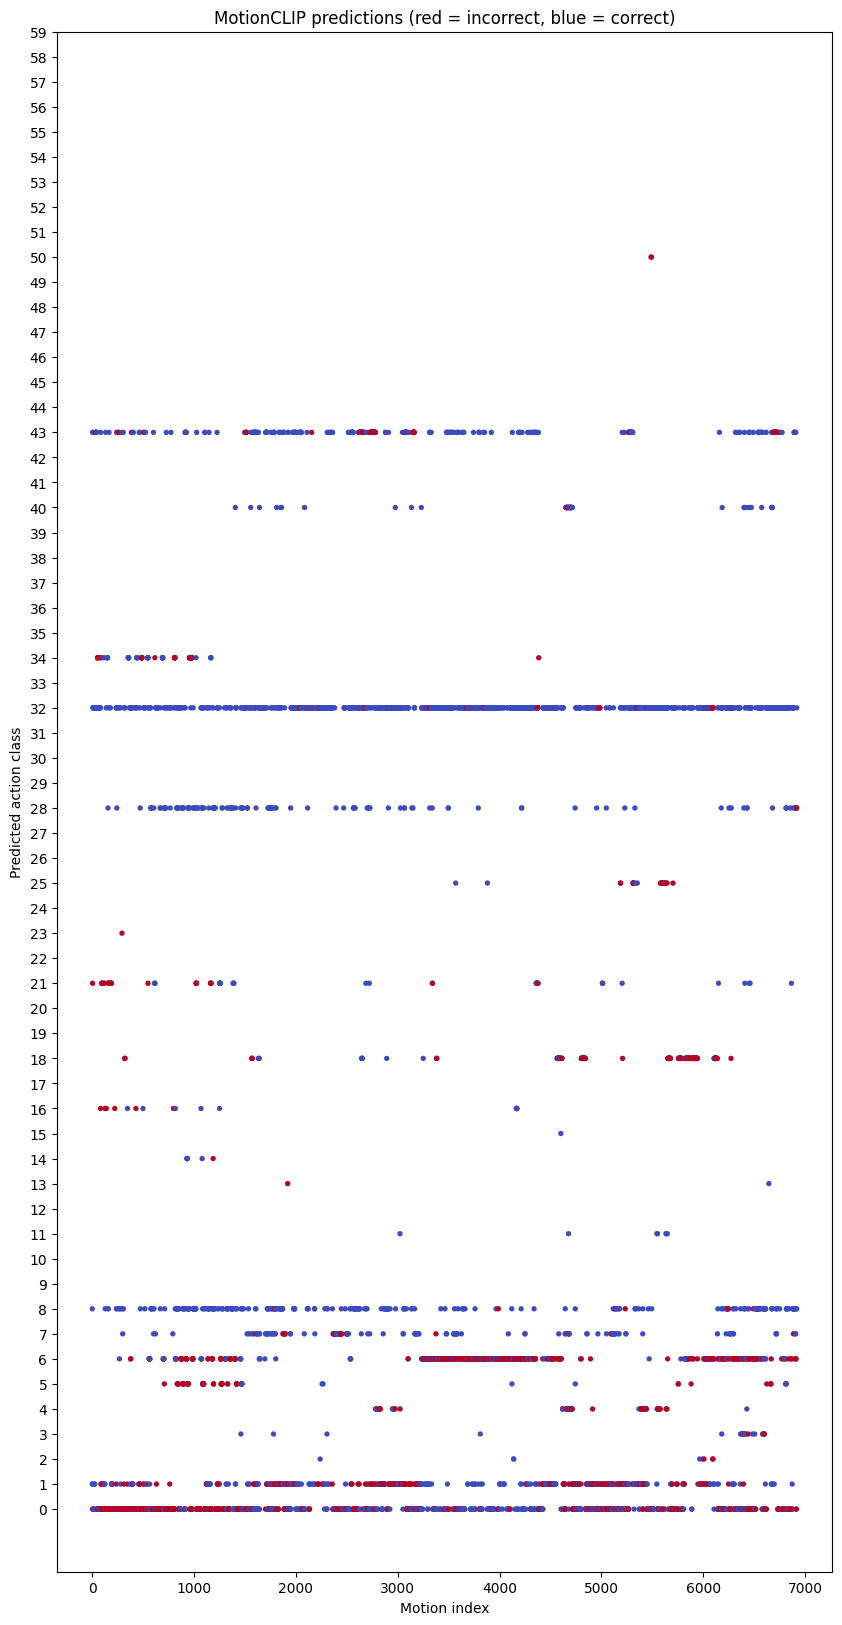

In [139]:
plt.figure(figsize=(10, 20))
plt.scatter(
    df.index,
    df["predicted"],
    c=df["correct"],
    cmap="coolwarm",
    s=8
)
plt.yticks(range(60))
plt.xlabel("Motion index")
plt.ylabel("Predicted action class")
plt.title("MotionCLIP predictions (red = incorrect, blue = correct)")
plt.show()

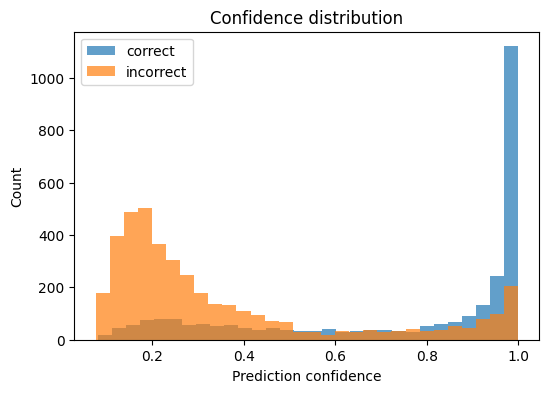

In [140]:
plt.figure(figsize=(6, 4))
plt.hist(df[df["correct"]]["confidence"], bins=30, alpha=0.7, label="correct")
plt.hist(df[~df["correct"]]["confidence"], bins=30, alpha=0.7, label="incorrect")
plt.xlabel("Prediction confidence")
plt.ylabel("Count")
plt.legend()
plt.title("Confidence distribution")
plt.show()

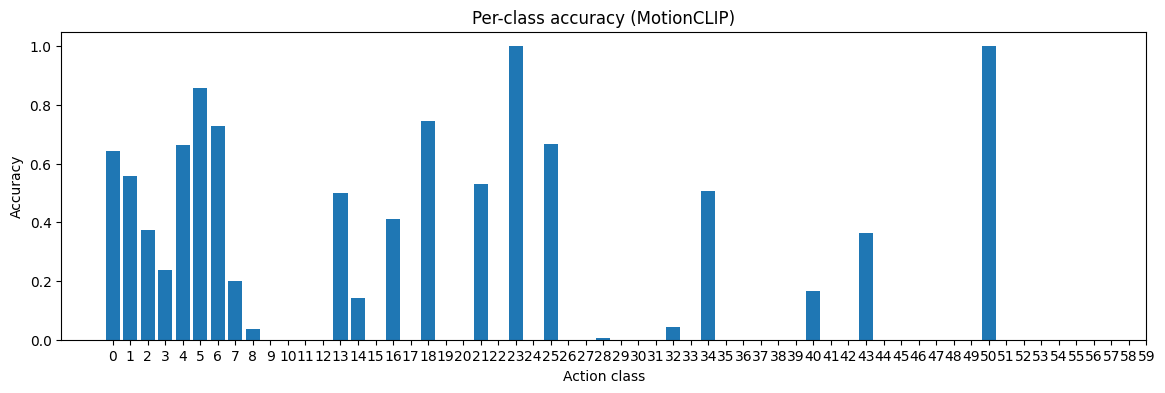

In [142]:
acc_per_class = {
    c: df[df["predicted"] == c]["correct"].mean()
    for c in range(60)
}

plt.figure(figsize=(14, 4))
plt.bar(acc_per_class.keys(), acc_per_class.values())

plt.xticks(
    ticks=list(range(60)),
    labels=list(range(60))
)

plt.xlabel("Action class")
plt.ylabel("Accuracy")
plt.title("Per-class accuracy (MotionCLIP)")
plt.show()

### MotionCLIP + Anomaly Detection Analysis

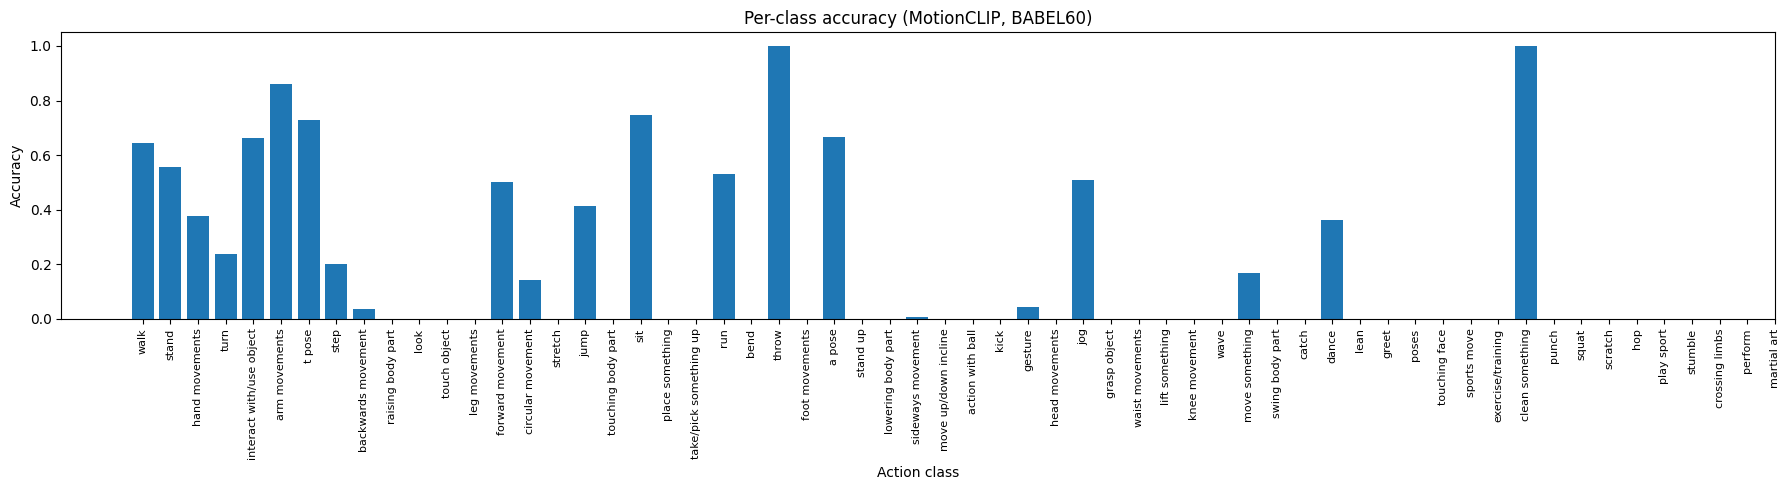

In [429]:
# acc_per_class: {class_id: accuracy}
class_ids = list(range(60))
accuracies = [acc_per_class[c] for c in class_ids]
class_names = [idx_to_action_label[c] for c in class_ids]

plt.figure(figsize=(18, 5))
plt.bar(class_ids, accuracies)

plt.xticks(
    ticks=class_ids,
    labels=class_names,
    rotation=90,
    fontsize=8
)

plt.xlabel("Action class")
plt.ylabel("Accuracy")
plt.title("Per-class accuracy (MotionCLIP, BABEL60)")
plt.tight_layout()
plt.savefig("data/sanity_check/validationSet_accuracy", dpi=300, bbox_inches="tight")
plt.show()


In [159]:
import math
bad_classes = {
    c: v
    for c, v in acc_per_class.items()
    if not math.isfinite(v)
}

len(bad_classes.keys())

36

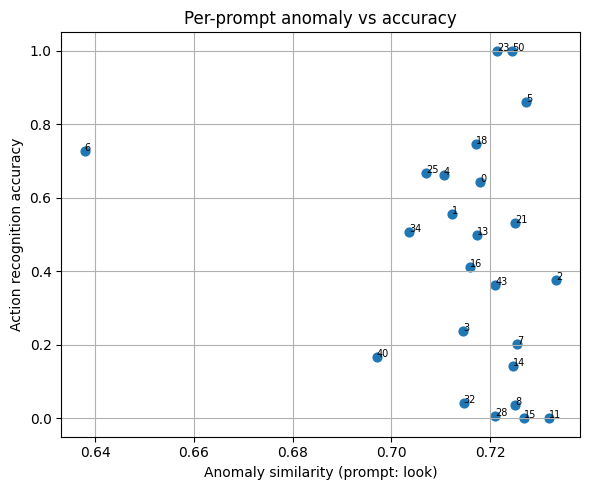

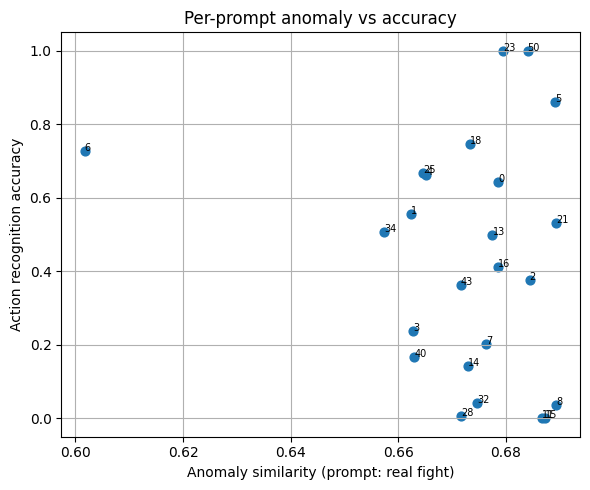

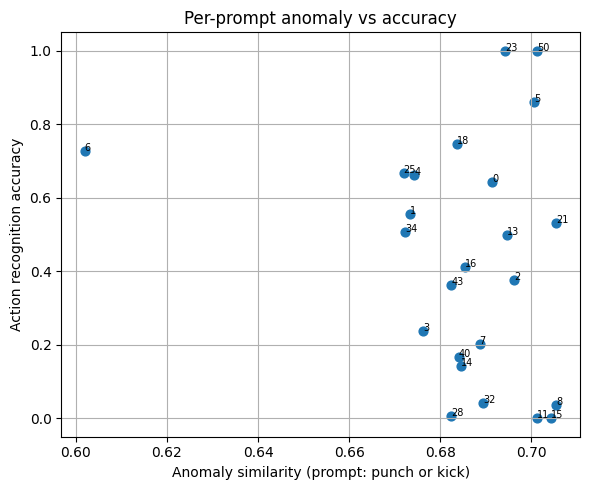

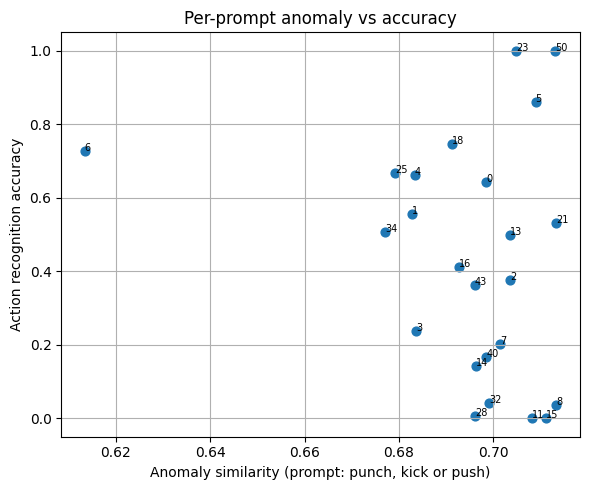

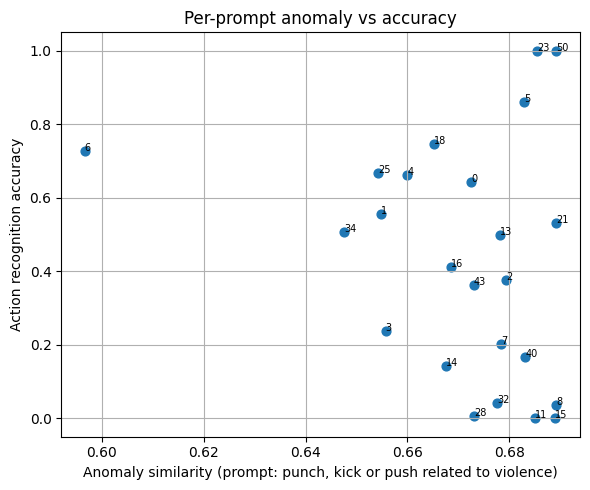

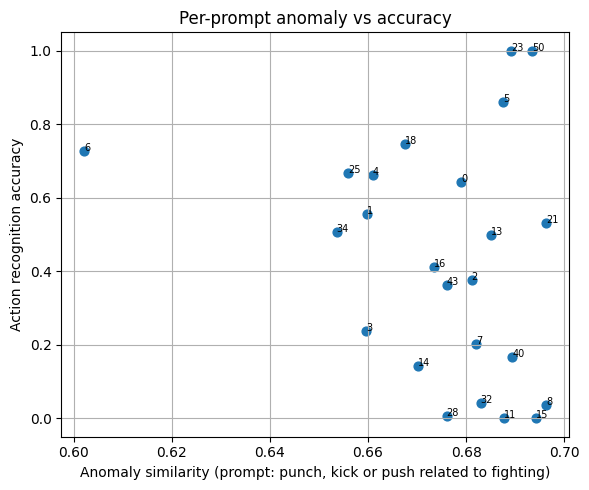

In [169]:
acc = np.array([acc_per_class[c] for c in range(60)])
for i in range(len(anomaly_prompts)):
    p = i

    x = similarity_scores[:, p].cpu().numpy()
    y = acc

    # valid = finite anomaly score AND finite accuracy
    valid = np.isfinite(x) & np.isfinite(y)

    plt.figure(figsize=(6, 5))
    plt.scatter(x[valid], y[valid], s=40)

    for c in np.where(valid)[0]:
        plt.text(x[c], y[c], str(c), fontsize=7)

    plt.xlabel(f"Anomaly similarity (prompt: {anomaly_prompts[p]})")
    plt.ylabel("Action recognition accuracy")
    plt.title("Per-prompt anomaly vs accuracy")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Take average of the motions (consider all motions)

In [423]:
from collections import defaultdict

def group_motion_embeddings_by_label(motion_embeddings, labels, num_labels=60):
    """
    motion_embeddings: Tensor (N, D)
    labels: list of length N, each element is int or list[int]

    Returns:
        label_to_embeds: dict[label -> Tensor (K, D)]
    """
    label_to_embeds = defaultdict(list)

    for i, lbls in enumerate(labels):
        if isinstance(lbls, int):
            lbls = [lbls]

        for lbl in lbls:
            if 0 <= lbl < num_labels:
                label_to_embeds[lbl].append(motion_embeddings[i])

    # stack lists into tensors
    for lbl in label_to_embeds:
        label_to_embeds[lbl] = torch.stack(label_to_embeds[lbl], dim=0)

    return label_to_embeds

In [424]:
def compute_mean_similarity_per_label(label_to_embeds, z_t, num_labels=60):
    """
    label_to_embeds: dict[label -> Tensor (K, D)]
    z_t: Tensor (P, D)

    Returns:
        similarities: Tensor (num_labels, P) with NaNs for missing labels
    """
    P = z_t.shape[0]
    similarities = torch.full((num_labels, P), float("nan"), device=z_t.device)

    for lbl, embeds in label_to_embeds.items():
        # embeds: (K, D)
        # z_t: (P, D)
        # -> sims: (K, P)
        sims = embeds @ z_t.T

        # mean over motions (K)
        similarities[lbl] = sims.mean(dim=0)

    return similarities


In [425]:
label_to_embeds = group_motion_embeddings_by_label(
    motion_embeddings_labels["motion_embeddings"], labels, num_labels=60
)

similarity_scores_all = compute_mean_similarity_per_label(
    label_to_embeds,
    encoded_prompts,   # z_t, shape (P, D)
    num_labels=60
)

In [426]:
print(similarity_scores_all.shape)

torch.Size([60, 4])


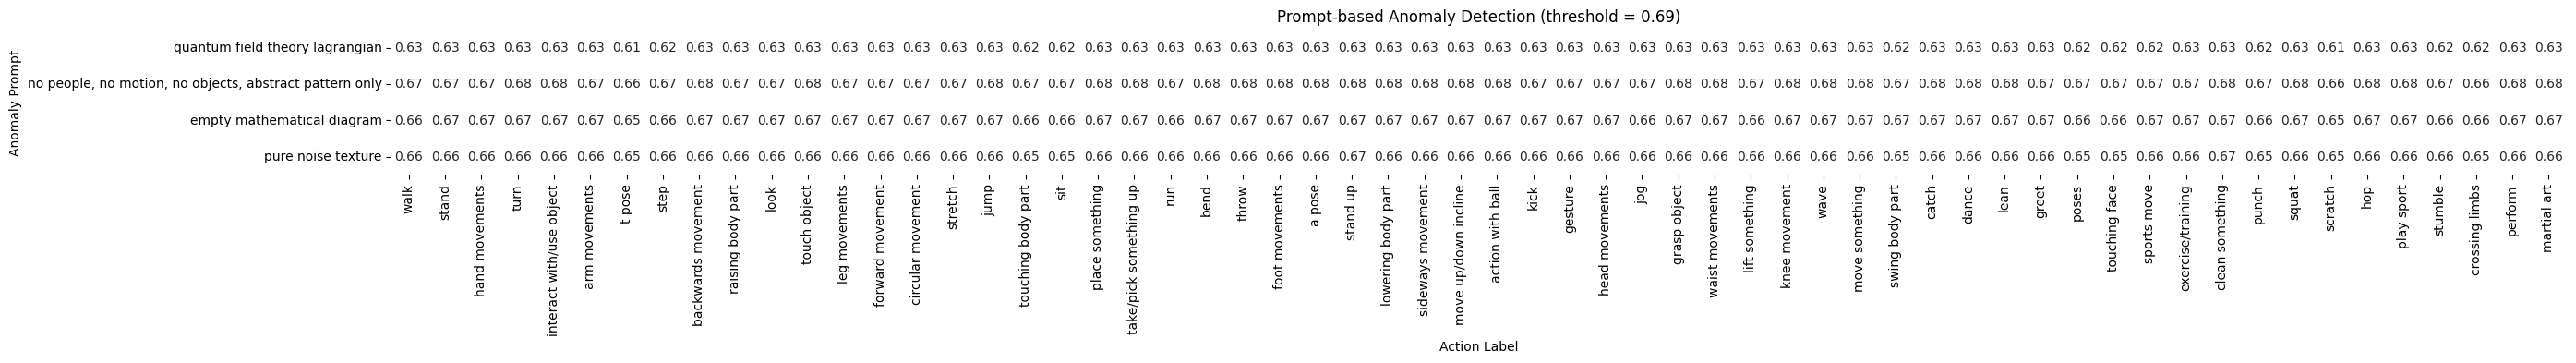

In [428]:
idx_to_action_label = {v: k for k, v in action_label_to_idx.items()}
threshold = 0.69
scores_df_all = pd.DataFrame(
    similarity_scores_all.T.cpu().numpy(),
    index=anomaly_prompts,
    columns=[idx_to_action_label[lbl] for lbl in range(60)]
)
mask = scores_df_all < threshold
plt.figure(figsize=(28, 10))

# Base layer: show all scores as numbers, white background
sns.heatmap(
    scores_df_all,
    cmap=["white"],
    cbar=False,
    annot=scores_df_all.round(2),
    fmt=".2f",
    square=True,
    linewidths=0.5
)

# Overlay: highlight only scores >= threshold in green
sns.heatmap(
    scores_df_all,
    mask=mask,
    cmap="Greens",
    vmin=0.5,
    vmax=scores_df_all.values.max(),
    cbar=False,
    annot=False,
    square=True
)

plt.title(f"Prompt-based Anomaly Detection (threshold = {threshold})")
plt.xlabel("Action Label")
plt.ylabel("Anomaly Prompt")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("data/sanity_check/randomPrompts_anomalyHeatmap", dpi=300, bbox_inches="tight")
plt.show()

### Per-prompt normalization

In [263]:
def zscore_per_prompt(similarities):
    """
    similarities: Tensor (num_labels, num_prompts)
    Returns:
        z_scores: Tensor (num_labels, num_prompts)
    """
    mask = ~torch.isnan(similarities)

    # mean over labels per prompt
    mu = (similarities * mask).sum(dim=0, keepdim=True) / mask.sum(dim=0, keepdim=True)

    # variance
    var = ((similarities - mu)**2 * mask).sum(dim=0, keepdim=True) / mask.sum(dim=0, keepdim=True)
    sigma = torch.sqrt(var + 1e-8)

    z = (similarities - mu) / sigma
    return z


In [264]:
z_scores_all = zscore_per_prompt(similarity_scores_all)

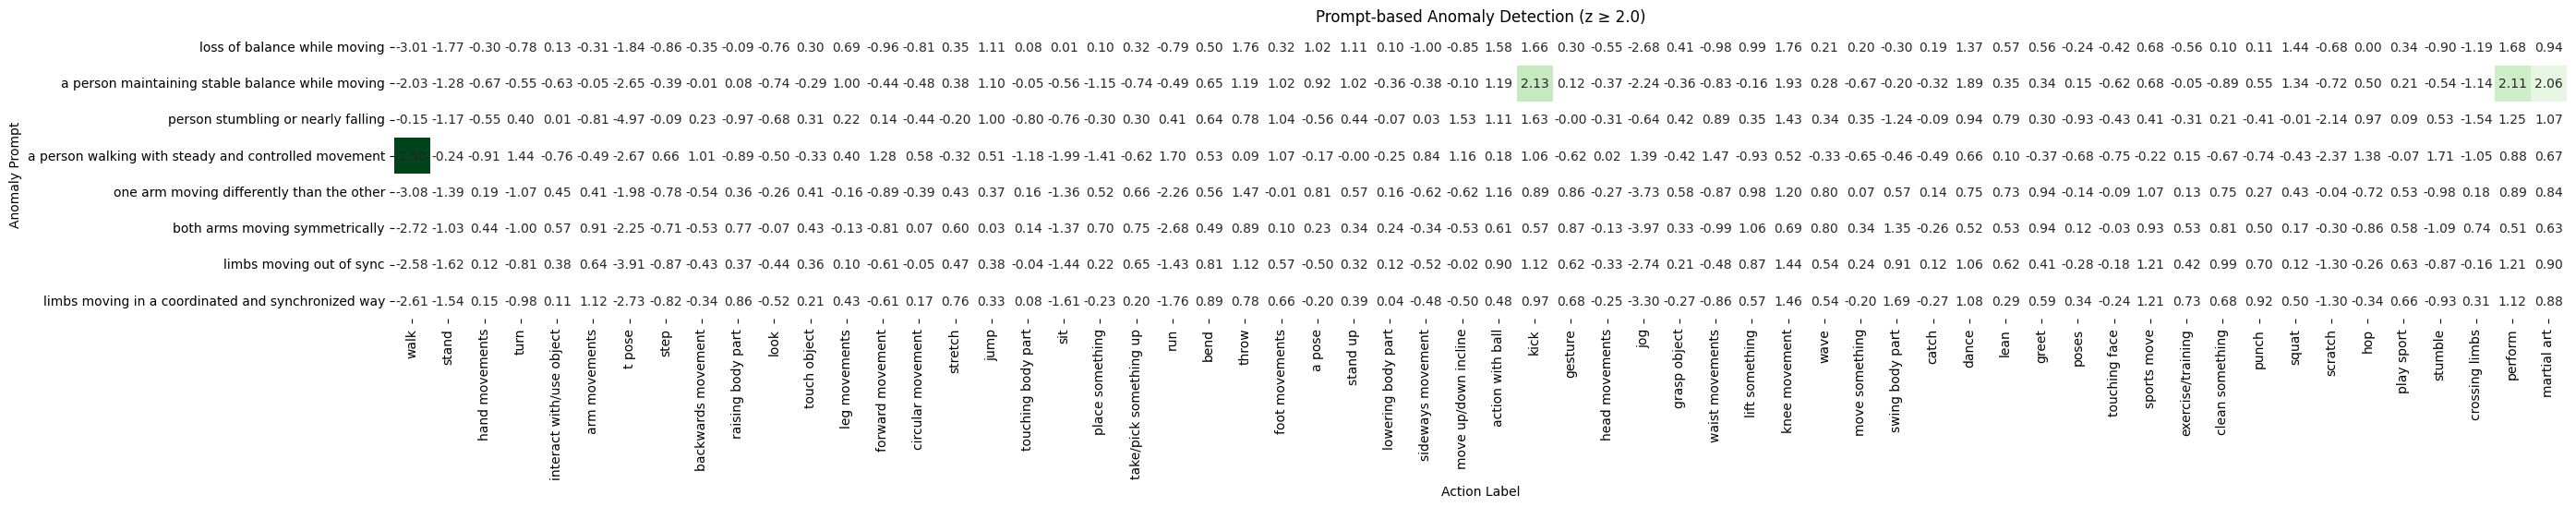

In [267]:
threshold = 0.69
mask = scores_df_all < threshold
z_threshold = 2.0   # strong positive deviation

idx_to_action_label = {v: k for k, v in action_label_to_idx.items()}

scores_df = pd.DataFrame(
    similarity_scores_all.T.cpu().numpy(),
    index=anomaly_prompts,
    columns=[idx_to_action_label[i] for i in range(60)]
)

z_df = pd.DataFrame(
    z_scores_all.T.cpu().numpy(),
    index=anomaly_prompts,
    columns=[idx_to_action_label[i] for i in range(60)]
)
anomaly_df = (z_df >= z_threshold).astype(int)
mask = z_df < z_threshold

plt.figure(figsize=(28, 10))

# Base layer: show z-scores as numbers, white background
sns.heatmap(
    z_df,
    cmap=["white"],
    cbar=False,
    annot=z_df.round(2),
    fmt=".2f",
    square=True,
    linewidths=0.5
)

# Overlay: highlight anomalies (z >= threshold) in green
sns.heatmap(
    z_df,
    mask=mask,          # hide non-anomalies
    cmap="Greens",
    vmin=z_threshold,
    vmax=z_df.values.max(),
    cbar=False,
    annot=False,
    square=True
)

plt.title(f"Prompt-based Anomaly Detection (z ≥ {z_threshold})")
plt.xlabel("Action Label")
plt.ylabel("Anomaly Prompt")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
# plt.figure(figsize=(28, 10))
# sns.heatmap(
#     z_df,
#     cmap="coolwarm",
#     center=0.0,
#     annot=z_df.round(2),
#     fmt=".2f",
#     square=True
# )
# plt.title("Per-prompt Z-score Normalized Similarity")
# plt.xlabel("Action Label")
# plt.ylabel("Anomaly Prompt")
# plt.xticks(rotation=90)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(28, 10))

# # Base: raw cosine similarity
# sns.heatmap(
#     scores_df,
#     cmap=["white"],
#     cbar=False,
#     annot=scores_df.round(2),
#     fmt=".2f",
#     square=True,
#     linewidths=0.5
# )

# # Overlay: anomalous labels (z-score)
# sns.heatmap(
#     scores_df,
#     mask=mask,
#     cmap="Greens",
#     vmin=scores_df.values.min(),
#     vmax=scores_df.values.max(),
#     cbar=False,
#     annot=False,
#     square=True
# )

# plt.title(f"Prompt-based Anomaly Detection (z ≥ {z_threshold})")
# plt.xlabel("Action Label")
# plt.ylabel("Anomaly Prompt")
# plt.xticks(rotation=90)
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

### Delta-to-neutral normalization

### This needs the anomaly and neutral prompt to be alternating (one anomaly, then neutral and so on)

In [268]:
def delta_to_neutral_pairs(similarities):
    """
    similarities: Tensor (num_labels, num_prompts)
                  prompts ordered as [anom0, neut0, anom1, neut1, ...]

    Returns:
        delta: Tensor (num_labels, num_anomaly_prompts)
    """
    assert similarities.shape[1] % 2 == 0, "Prompts must be in anomaly/neutral pairs"

    deltas = []
    anomaly_indices = []

    for i in range(0, similarities.shape[1], 2):
        anom_idx = i
        neut_idx = i + 1

        delta = similarities[:, anom_idx] - similarities[:, neut_idx]
        deltas.append(delta)
        anomaly_indices.append(anom_idx)

    delta = torch.stack(deltas, dim=1)  # (num_labels, num_anomaly_prompts)
    return delta, anomaly_indices


In [270]:
delta_scores, anomaly_prompt_indices = delta_to_neutral_pairs(similarity_scores_all)
z_delta_scores = zscore_per_prompt(delta_scores)

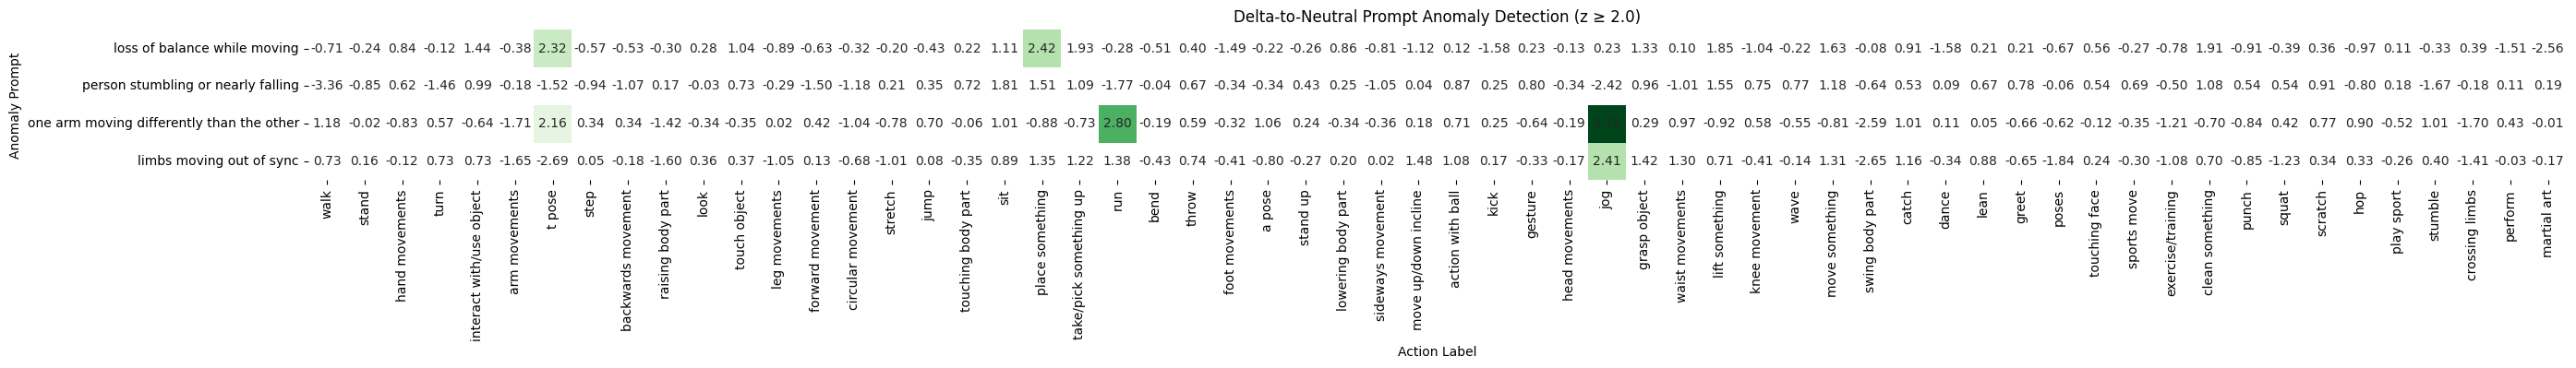

In [271]:
idx_to_action_label = {v: k for k, v in action_label_to_idx.items()}

anomaly_only_prompts = [anomaly_prompts[i] for i in anomaly_prompt_indices]

z_delta_df = pd.DataFrame(
    z_delta_scores.T.cpu().numpy(),
    index=anomaly_only_prompts,
    columns=[idx_to_action_label[i] for i in range(60)]
)

z_threshold = 2.0
mask = z_delta_df < z_threshold

plt.figure(figsize=(28, 10))

# Base: show z-scores
sns.heatmap(
    z_delta_df,
    cmap=["white"],
    cbar=False,
    annot=z_delta_df.round(2),
    fmt=".2f",
    square=True,
    linewidths=0.5
)

# Overlay: anomalies
sns.heatmap(
    z_delta_df,
    mask=mask,
    cmap="Greens",
    vmin=z_threshold,
    vmax=z_delta_df.values.max(),
    cbar=False,
    annot=False,
    square=True
)

plt.title(f"Delta-to-Neutral Prompt Anomaly Detection (z ≥ {z_threshold})")
plt.xlabel("Action Label")
plt.ylabel("Anomaly Prompt")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Cosine similarity of the paper experiment

In [333]:
data = torch.load("motionclip_action_recognition_outputs_cosineScores.pt")

S = data["similarities"]   # (N, C)
labels = data["labels"]    # list[list[int]]

C:\Users\meenakshi\AppData\Local\Temp\ipykernel_8716\1042937695.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("motionclip_action_recognition_outputs_

In [337]:
print(len(labels))

6911


In [338]:
pred_idx = S.argmax(dim=1)                 # (N,)
pred_sim = S[torch.arange(S.size(0)), pred_idx]

In [339]:
gt_sim = torch.tensor([
    S[i, labels[i]].mean().item()
    for i in range(len(labels))
])


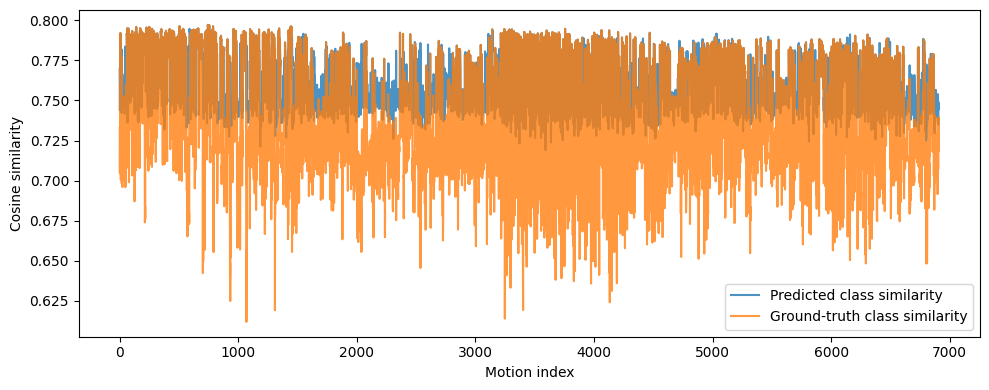

In [340]:
plt.figure(figsize=(10, 4))
plt.plot(pred_sim.cpu(), label="Predicted class similarity", alpha=0.8)
plt.plot(gt_sim.cpu(), label="Ground-truth class similarity", alpha=0.8)

plt.xlabel("Motion index")
plt.ylabel("Cosine similarity")
plt.legend()
plt.tight_layout()

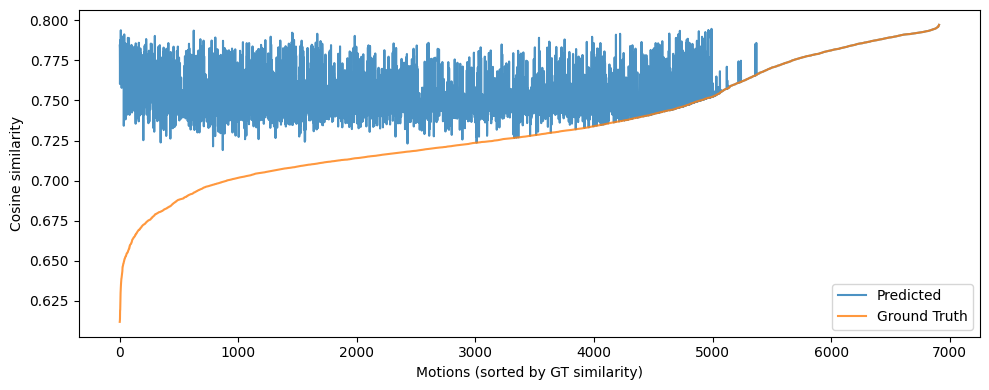

In [341]:
order = torch.argsort(gt_sim)

plt.figure(figsize=(10, 4))
plt.plot(pred_sim[order].cpu(), label="Predicted", alpha=0.8)
plt.plot(gt_sim[order].cpu(), label="Ground Truth", alpha=0.8)

plt.xlabel("Motions (sorted by GT similarity)")
plt.ylabel("Cosine similarity")
plt.legend()
plt.tight_layout()


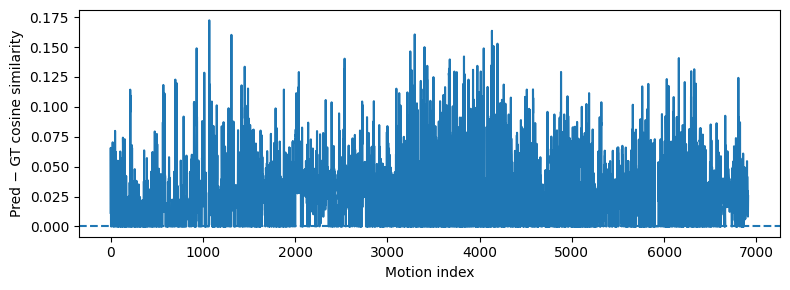

In [342]:
margin = pred_sim - gt_sim

plt.figure(figsize=(8, 3))
plt.plot(margin.cpu())
plt.axhline(0, linestyle="--")
plt.xlabel("Motion index")
plt.ylabel("Pred − GT cosine similarity")
plt.tight_layout()


In [343]:
is_correct = torch.tensor([
    pred_idx[i].item() in labels[i]
    for i in range(len(labels))
])

In [344]:
pred_sim_correct = pred_sim[is_correct]
gt_sim_correct   = gt_sim[is_correct]

pred_sim_wrong = pred_sim[~is_correct]
gt_sim_wrong   = gt_sim[~is_correct]

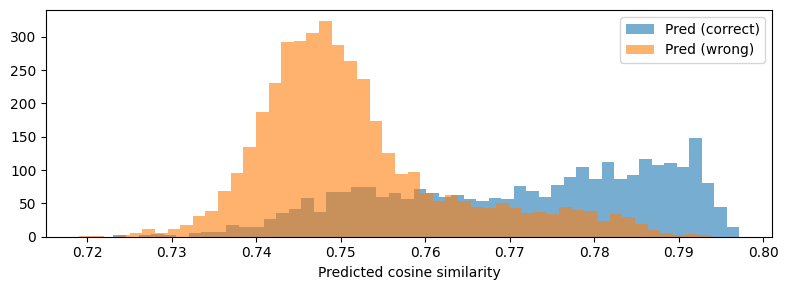

In [345]:
plt.figure(figsize=(8, 3))

plt.hist(pred_sim_correct.cpu(), bins=50, alpha=0.6, label="Pred (correct)")
plt.hist(pred_sim_wrong.cpu(), bins=50, alpha=0.6, label="Pred (wrong)")

plt.xlabel("Predicted cosine similarity")
plt.legend()
plt.tight_layout()


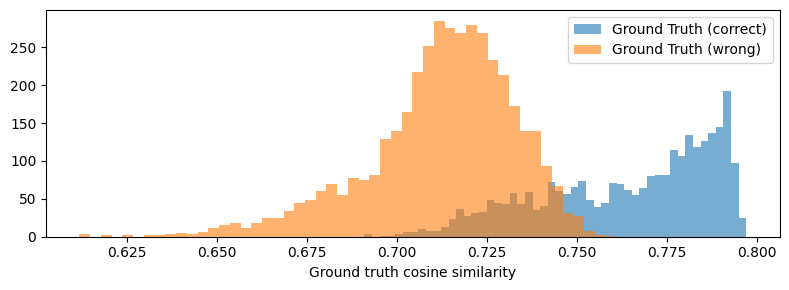

In [346]:
plt.figure(figsize=(8, 3))

plt.hist(gt_sim_correct.cpu(), bins=50, alpha=0.6, label="Ground Truth (correct)")
plt.hist(gt_sim_wrong.cpu(), bins=50, alpha=0.6, label="Ground Truth (wrong)")

plt.xlabel("Ground truth cosine similarity")
plt.legend()
plt.tight_layout()


In [347]:
pred_sim_correct.mean(), pred_sim_wrong.mean()

(tensor(0.7713), tensor(0.7515))

In [348]:
gt_sim_correct.mean(), gt_sim_wrong.mean()


(tensor(0.7642), tensor(0.7124))

### Compute mean cosine similarity for correctly predicted motions per class

In [363]:
from collections import defaultdict

per_class_c_sim = defaultdict(list)

for i in range(len(labels)):
    c = pred_idx[i].item()

    gt = labels[i]
    if isinstance(gt, str):
        gt = [gt]
    gt_idxs = [idx_to_action_label[x] for x in gt]
    if c in gt:
        per_class_c_sim[c].append(S[i, c].item())

In [419]:
print(min(per_class_c_sim[action_label_to_idx["stand"]]), max(per_class_c_sim[action_label_to_idx["stand"]]))

0.7281093597412109 0.7886701822280884


In [319]:
len(df), S.shape[0], len(labels), len(pred_idx)

(6920, 6911, 20, 6911)

### Action recognition - compute number of samples per class

In [386]:
from collections import defaultdict

num_classes = 60
count_per_class = defaultdict(int)

for lbls in labels:
    if isinstance(lbls, int):
        lbls = [lbls]

    for lbl in lbls:
        if 0 <= lbl < num_classes:
            count_per_class[lbl] += 1


In [387]:
class_ids = list(range(num_classes))
counts = [count_per_class.get(c, 0) for c in class_ids]
class_names = [idx_to_action_label[c] for c in class_ids]

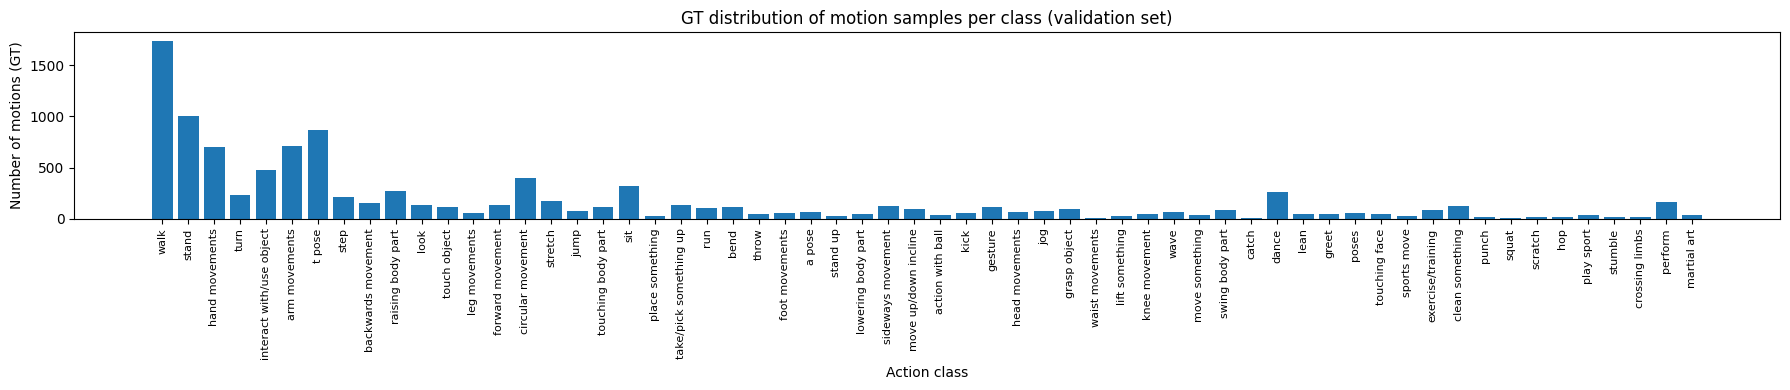

In [430]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 4))
plt.bar(class_ids, counts)

plt.xticks(
    ticks=class_ids,
    labels=class_names,
    rotation=90,
    fontsize=8
)

plt.xlabel("Action class")
plt.ylabel("Number of motions (GT)")
plt.title("GT distribution of motion samples per class (validation set)")
plt.tight_layout()
plt.savefig("data/sanity_check/validationSamples_perClass", dpi=300, bbox_inches="tight")
plt.show()

### OLD CODE

### Get text embeddings of the label

In [30]:
num_classes = 60

In [4]:
# class_sizes = list(range(60))
classes = list(action_label_to_idx.keys()) 


clip_model, preprocess = clip.load("ViT-B/32", device=device, download_root=os.environ["CLIP_CACHE_DIR"])

# for class_size in class_sizes:
    # classes_subset = classes[:class_size]
    
    # prompts = [f"a person performing {name}" for name in classes_subset]

with torch.no_grad():
    tokens = clip.tokenize(classes[:60]).to(device)

    text_embeddings = clip_model.encode_text(tokens)

    text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

    filename = f"text_embeddings_{60}_classes.pt"
    torch.save(text_embeddings.cpu(), f"data/sanity_check/text_embeddings/{filename}")
    print(f"Saved {filename}")


Saved text_embeddings_60_classes.pt


### Get motion_embeddings

In [5]:
print("Current working dir:", os.getcwd())

ckpt_path = "../classes-model/checkpoint_0200.pth.tar"

sys.argv = ["program", "--cuda", ckpt_path]
parameters, folder, checkpointname, epoch = parser(checkpoint=True)
parameters["device"] = device
parameters["dataset"] = "babel"
parameters["datapath"] = "data/amass_db/babel_30fps_db.pt" #this one has 384 unique classes
parameters["babel_dir"] = "data/babel_v1.0_release"
parameters["target_fps"] = 30
parameters['only_60_classes'] = True


assert os.path.exists("data/amass_db")

model, datasets = get_model_and_data(parameters, split="train")
ckpt_path = os.path.join(folder, checkpointname)
state_dict = torch.load(ckpt_path, map_location=device)
load_model_wo_clip(model, state_dict)

for p in model.parameters():
    p.requires_grad = False
model.eval()

Current working dir: d:\Delft\Uni\Thesis\MotionCLIP_experiment\MotionCLIP
datapath used by amass is [data/amass_db/babel_30fps_train.pt]
datapath used by amass is [data/amass_db/babel_30fps_train.pt]


d:\anaconda3\envs\motionclip\lib\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
C:\Users\meenakshi\AppData\Local\Temp\ipykernel_14152\852908339.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be a

MOTIONCLIP(
  (encoder): Encoder_TRANSFORMER(
    (skelEmbedding): Linear(in_features=150, out_features=512, bias=True)
    (sequence_pos_encoder): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (seqTransEncoder): TransformerEncoder(
      (layers): ModuleList(
        (0-7): 8 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
          )
          (linear1): Linear(in_features=512, out_features=1024, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=1024, out_features=512, bias=True)
          (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (decoder): Decoder_TRANSFO

In [6]:
print(datasets.keys())

dict_keys(['train', 'test'])


In [7]:
all_latents, all_labels = [], []
with torch.no_grad():
    for i, sample in enumerate(tqdm(datasets["test"])):
        if sample is None or "inp" not in sample:
            continue
        motion = sample["inp"].to(device).unsqueeze(0)
        label  = sample["y"]             
        T = motion.shape[-1]
        mask = torch.ones(1, T, dtype=torch.bool, device=device)
        batch = {"x": motion, "y": torch.tensor([label], dtype=torch.long, device=device), "mask": mask}

        z_out = model.encoder(batch)  
        z_p = z_out["mu"]     
        z_p = z_p / z_p.norm(dim=-1, keepdim=True)  
        all_latents.append(z_p.cpu())
        all_labels.append(label)
print(torch.unique(torch.tensor(all_labels)))

100%|██████████| 20112/20112 [07:33<00:00, 44.33it/s]


tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
        54, 55, 56, 57, 58, 59])


### Get the  chosen motion embedding

In [8]:
def get_embedding_by_label(target_label):
    all_labels_tensor = torch.tensor(all_labels)
    
    indices = (all_labels_tensor == target_label).nonzero(as_tuple=True)[0]
    
    if len(indices) > 0:
        embeddings = [all_latents[i] for i in indices]
        return embeddings
    else:
        print(f"Label {target_label} not found!")
        return None

### Get one motion embedding per class

In [32]:
class_embeddings = []

for c in range(60):
    embeds = get_embedding_by_label(c)
    if embeds is not None:
        class_embeddings.append(embeds[0])  # pick first occurrence

In [ ]:
# text_embeds = torch.load(

#     "data/sanity_check/text_embeddings/text_embeddings_60_classes.pt"
# ).to(device)

C:\Users\meenakshi\AppData\Local\Temp\ipykernel_6420\3691989623.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  text_embeds = torch.load(


In [ ]:
# motion_embeds = torch.stack(all_latents).squeeze(1).to(device)
# motion_embeds = torch.nn.functional.normalize(motion_embeds, dim=1)
# text_embeds   = torch.nn.functional.normalize(text_embeds, dim=1)

# logits = motion_embeds @ text_embeds.T   # [60, 60]

# probs = torch.softmax(logits, dim=1)

In [9]:
# motion embeddings for ALL test motions
motion_embeds = torch.stack(all_latents).squeeze(1).to(device)

# text embeddings
text_embeds = torch.load(
    "data/sanity_check/text_embeddings/text_embeddings_60_classes.pt"
).to(device)
text_embeds = torch.nn.functional.normalize(text_embeds, dim=1)

# logits per motion
logits = motion_embeds @ text_embeds.T   # [N, 60]

# targets
targets = torch.tensor(all_labels, device=device)

# metrics
top1 = (logits.argmax(dim=1) == targets).float().mean().item()
top5 = (logits.topk(5, dim=1).indices == targets.unsqueeze(1)) \
       .any(dim=1).float().mean().item()


C:\Users\meenakshi\AppData\Local\Temp\ipykernel_14152\89192297.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  text_embeds = torch.load(


In [11]:
print(motion_embeds.shape)
print(logits.shape)

torch.Size([18097, 512])
torch.Size([18097, 60])


In [46]:
# targets = torch.tensor(all_labels, device=device)
# top1 = (logits.argmax(dim=1) == targets).float().mean().item()

# top5 = (logits.topk(5, dim=1).indices == targets.unsqueeze(1)) \
#        .any(dim=1).float().mean().item()

In [12]:
print(top1)
print(top5)

0.5314140319824219
0.6698347926139832


In [13]:
logits.diag().mean().item(), logits.mean().item()

(0.6998649835586548, 0.6938307881355286)

### Heatmap

In [14]:
N, C = logits.shape

In [18]:
picked_indices = []
seen = set()

for i, y in enumerate(targets.tolist()):
    if y not in seen:
        picked_indices.append(i)
        seen.add(y)
    if len(seen) == num_classes:
        break

In [19]:
logits_1pc  = logits[picked_indices]    # [60, 60]
targets_1pc = targets[picked_indices]

In [22]:
order = torch.argsort(targets_1pc)
logits_1pc = logits_1pc[order]
targets_1pc = targets_1pc[order]

In [23]:
top1_idx = logits_1pc.argmax(dim=1)

top1_matrix = torch.zeros(num_classes, num_classes)
top1_matrix[torch.arange(num_classes), top1_idx] = 1


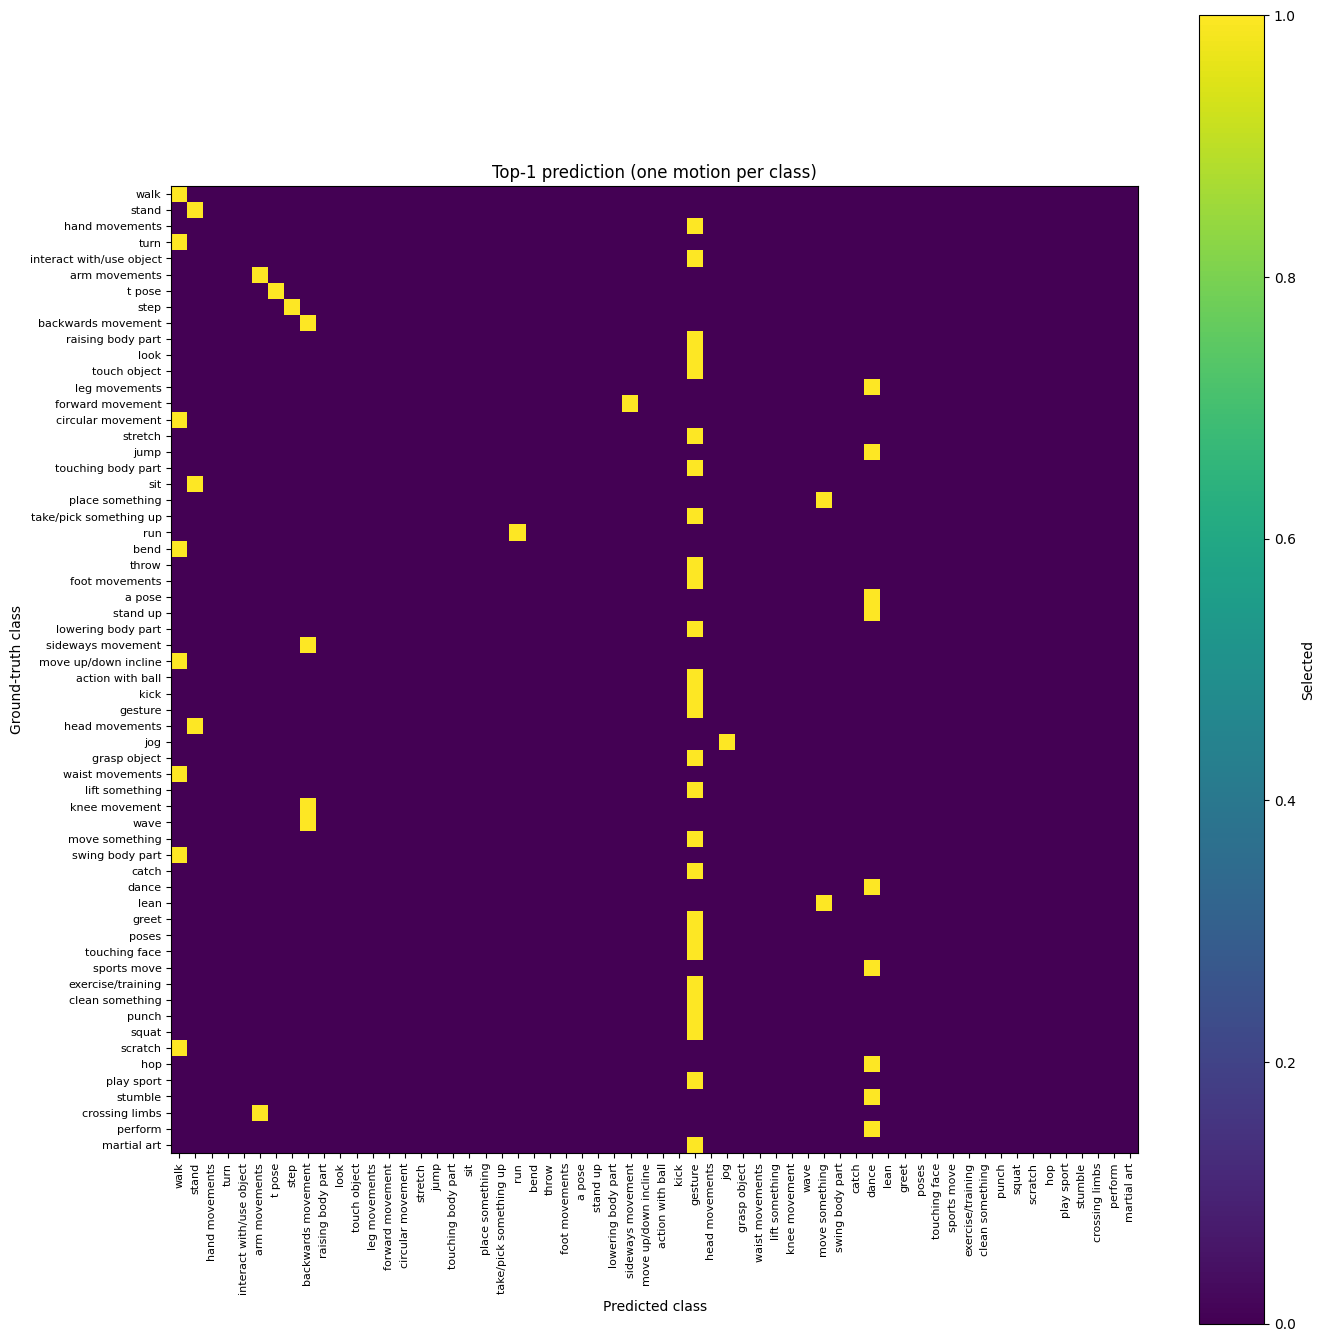

In [25]:
idx_to_action_label = {v: k for k, v in action_label_to_idx.items()}
class_names = [idx_to_action_label[i] for i in range(num_classes)]

plt.figure(figsize=(14, 14))
plt.imshow(top1_matrix.cpu(), aspect="equal", interpolation="nearest")

plt.xticks(range(num_classes), class_names, rotation=90, fontsize=8)
plt.yticks(range(num_classes), class_names, fontsize=8)

plt.xlabel("Predicted class")
plt.ylabel("Ground-truth class")
plt.title("Top-1 prediction (one motion per class)")

plt.colorbar(label="Selected")
plt.tight_layout()
plt.show()

### Top-5 heatmap

In [26]:
top5_idx = logits_1pc.topk(5, dim=1).indices   # [60, 5]

top5_matrix = torch.zeros(num_classes, num_classes)
for i in range(num_classes):
    top5_matrix[i, top5_idx[i]] = 1

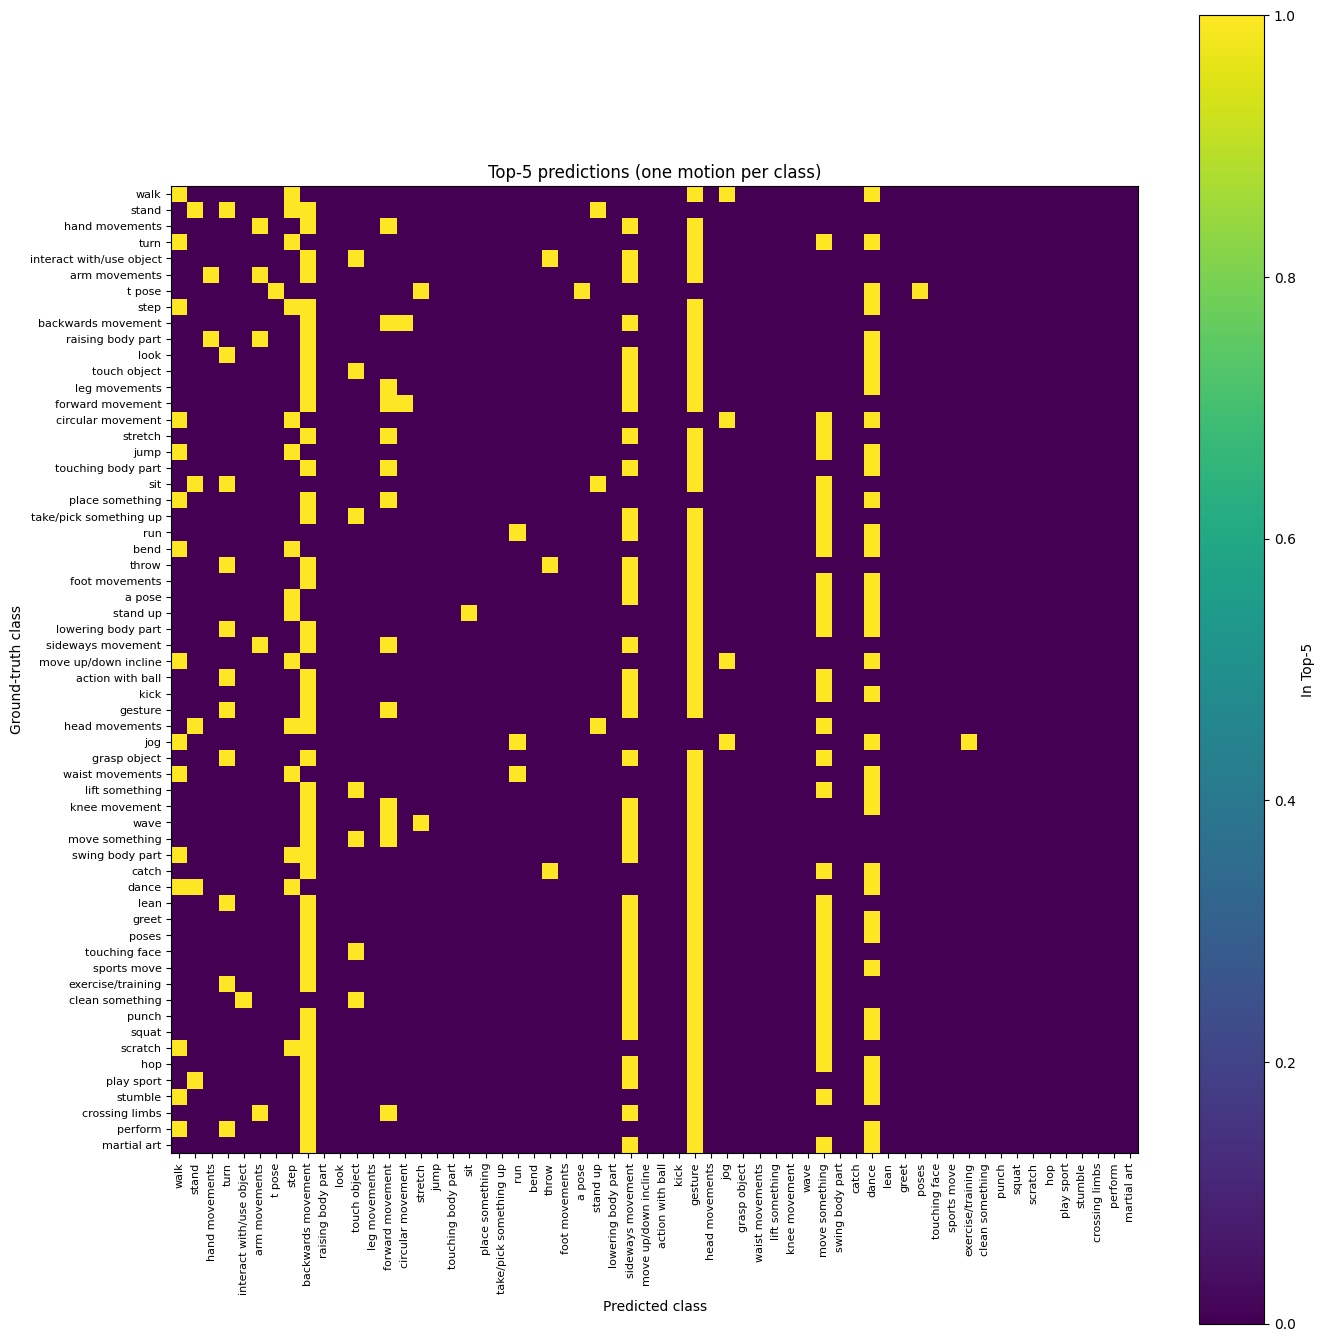

In [27]:
class_names = [idx_to_action_label[i] for i in range(num_classes)]

plt.figure(figsize=(14, 14))
plt.imshow(top5_matrix.cpu(), aspect="equal", interpolation="nearest")

plt.xticks(range(num_classes), class_names, rotation=90, fontsize=8)
plt.yticks(range(num_classes), class_names, fontsize=8)

plt.xlabel("Predicted class")
plt.ylabel("Ground-truth class")
plt.title("Top-5 predictions (one motion per class)")

plt.colorbar(label="In Top-5")
plt.tight_layout()
plt.show()